In [561]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, RealData

plt.rcParams["font.size"] = 18
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18

In [562]:
cesium_137_centroid = 450.58
cesium_137_fwhm = 33.2410


centroids = np.array(
    [
        789.62,
        894.58,
        211.72,
        249.95,
        45.69,
    ]
)

centroid_fwhm = np.array(
    [
        42,
        44,
        50,
        20,
        5,
    ]
)

energies = np.array(
    [
        1173.0,
        1332.5,
        302.85,
        356.0,
        59.6,
    ]
)

isotopes = np.array(
    [
        "Co-60",
        "Co-60",
        "Ba-133",
        "Ba-133",
        "Am-241",
    ]
)

In [563]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty


In [564]:
centroid_uncertainties = centroid_fwhm / (2 * np.sqrt(2 * np.log(2)))


def linear_func(beta, x):
    return beta[0] * x + beta[1]


data = RealData(centroids, energies, sx=centroid_uncertainties)
model = Model(linear_func)
odr = ODR(data, model, beta0=[1.5, 0])
output = odr.run()

slope = output.beta[0]
intercept = output.beta[1]
slope_unc = output.sd_beta[0]
intercept_unc = output.sd_beta[1]

slope_r, slope_unc_r = round_unc(slope, slope_unc)
intercept_r, intercept_unc_r = round_unc(intercept, intercept_unc)

print(
    f"Linear calibration: E = ({slope_r} ± {slope_unc_r}) keV/Ch × Ch + ({intercept_r} ± {intercept_unc_r}) keV"
)
print(f"Reduced chi-squared: {output.res_var:.3f}")


Linear calibration: E = (1.493 ± 0.009) keV/Ch × Ch + (-9.0 ± 1.5) keV
Reduced chi-squared: 0.167


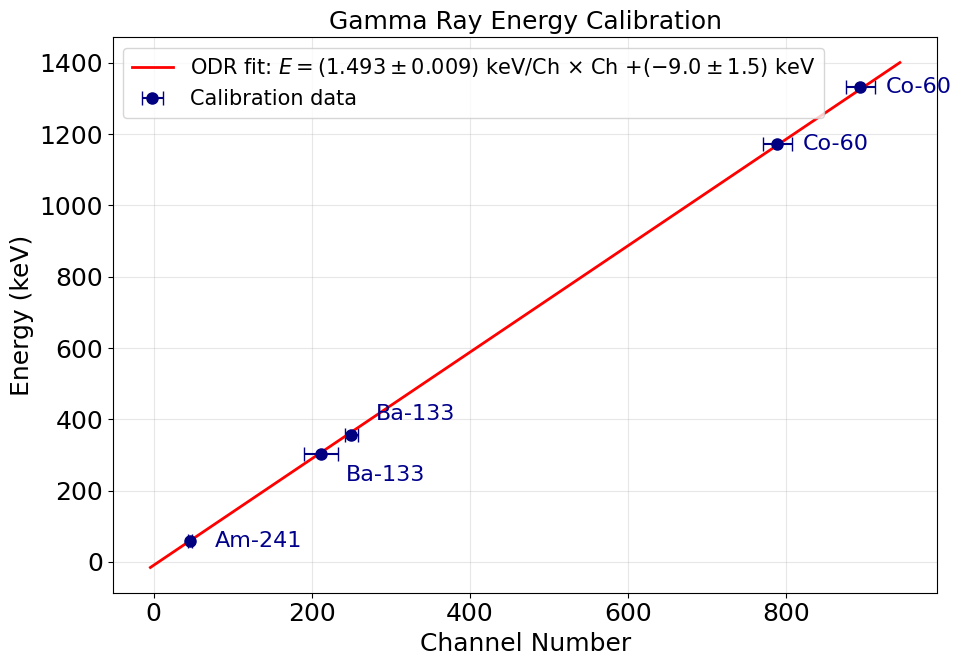

In [565]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    centroids,
    energies,
    xerr=centroid_uncertainties,
    fmt="o",
    markersize=8,
    capsize=5,
    label="Calibration data",
    color="navy",
)

offsets = [(18, 0), (18, 0), (18, -15), (18, 15), (18, 0)]

for i, isotope in enumerate(isotopes):
    ax.annotate(
        isotope,
        (centroids[i], energies[i]),
        xytext=offsets[i],
        textcoords="offset points",
        fontsize=16,
        color="darkblue",
        va="center",
    )

ch_fit = np.linspace(centroids.min() - 50, centroids.max() + 50, 200)
energy_fit = linear_func(output.beta, ch_fit)
ax.plot(
    ch_fit,
    energy_fit,
    "r-",
    linewidth=2,
    label=f"ODR fit: $E = ({slope_r} \\pm {slope_unc_r})$ keV/Ch $\\times$ Ch $+ ({intercept_r} \\pm {intercept_unc_r})$ keV",
)

ax.set_xlabel("Channel Number")
ax.set_ylabel("Energy (keV)")
ax.set_title("Gamma Ray Energy Calibration")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report/calibration.png", dpi=300, bbox_inches="tight")
plt.show()


In [566]:
def channel_to_energy(channel, channel_unc=None):
    """
    Convert channel number to energy with uncertainty.
    If channel_unc not provided, assumes 5% of FWHM based on typical detector resolution.
    """
    if channel_unc is None:
        typical_fwhm_ratio = 0.05
        channel_unc = channel * typical_fwhm_ratio / (2 * np.sqrt(2 * np.log(2)))

    energy = slope * channel + intercept

    energy_unc = np.sqrt(
        (slope * channel_unc) ** 2 + (channel * slope_unc) ** 2 + intercept_unc**2
    )

    return energy, energy_unc


df = pd.read_csv("cs137.csv")
df["channel"] = df.index
df["energy_keV"] = linear_func(output.beta, df["channel"])
df.head()

,intensity,channel,energy_keV
0,0,0,-9.047423
1,0,1,-7.554821
2,0,2,-6.062219
3,0,3,-4.569617
4,0,4,-3.077015


In [567]:
# CS-137 FEATURES

# - Compton edge
# - Compton plateau
# - Compton backscatter
# - X-ray peak
# - The true energy modes/peaks

cs_features = {
    "edge": 477.4,
    "plateau": {
        "start": 300,
        "end": 390,
    },
    "backscatter": 184.3,
    "xray": 28,
}


In [568]:
m_e_c2 = 511.0
cs137_energy_known = 661.7

E_gamma = cs137_energy_known

E_backscatter = E_gamma / (1 + 2 * E_gamma / m_e_c2)

E_compton_edge = E_gamma - E_backscatter

print("Compton Scattering Calculations for Cs-137")
print("=" * 60)
print(f"Initial photon energy (γ-ray): {E_gamma:.1f} keV")
print(f"Electron rest mass energy: {m_e_c2:.1f} keV")
print()
print(f"Backscatter peak energy (θ=180°): {E_backscatter:.1f} keV")
print(f"Compton edge energy: {E_compton_edge:.1f} keV")
print()
print(f"Comparison with cs_features dictionary:")
print(f"  Backscatter peak: {cs_features['backscatter']} keV")
print(f"  Compton edge: {cs_features['edge']} keV")


Compton Scattering Calculations for Cs-137
Initial photon energy (γ-ray): 661.7 keV
Electron rest mass energy: 511.0 keV

Backscatter peak energy (θ=180°): 184.3 keV
Compton edge energy: 477.4 keV

Comparison with cs_features dictionary:
  Backscatter peak: 184.3 keV
  Compton edge: 477.4 keV


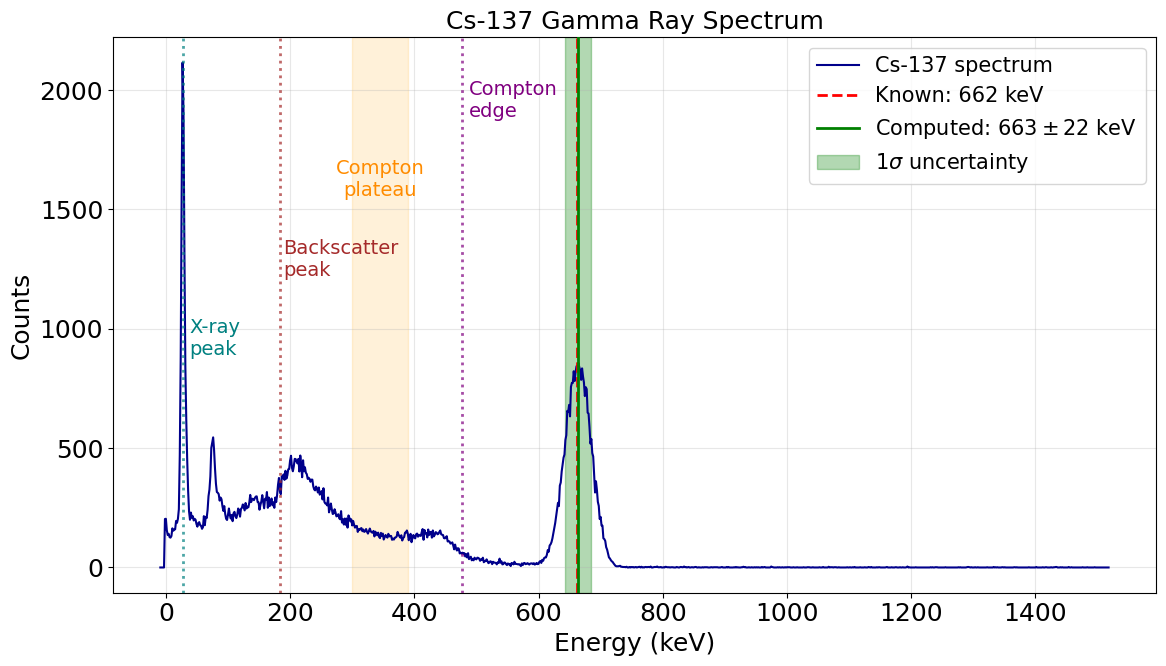

In [569]:
cs137_energy_known = 662
cs137_energy_computed, cs137_energy_unc = channel_to_energy(
    cesium_137_centroid, cesium_137_fwhm / (2 * np.sqrt(2 * np.log(2)))
)
cs137_energy_r, cs137_energy_unc_r = round_unc(cs137_energy_computed, cs137_energy_unc)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    df["energy_keV"],
    df["intensity"],
    linewidth=1.5,
    color="darkblue",
    label="Cs-137 spectrum",
)

ax.axvline(
    cs137_energy_known,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Known: {cs137_energy_known:.0f} keV",
    zorder=5,
)

ax.axvline(
    cs137_energy_computed,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Computed: ${cs137_energy_r:.0f} \\pm {cs137_energy_unc_r:.0f}$ keV",
    zorder=5,
)

ax.axvspan(
    cs137_energy_computed - cs137_energy_unc,
    cs137_energy_computed + cs137_energy_unc,
    alpha=0.3,
    color="green",
    label="$1\\sigma$ uncertainty",
)

ax.axvline(
    cs_features["edge"],
    color="purple",
    linestyle=":",
    linewidth=2,
    alpha=0.7,
    zorder=4,
)
ax.text(
    cs_features["edge"] + 10,
    ax.get_ylim()[1] * 0.85,
    "Compton\nedge",
    rotation=0,
    fontsize=14,
    color="purple",
)

ax.axvspan(
    cs_features["plateau"]["start"],
    cs_features["plateau"]["end"],
    alpha=0.15,
    color="orange",
    zorder=1,
)
ax.text(
    (cs_features["plateau"]["start"] + cs_features["plateau"]["end"]) / 2,
    ax.get_ylim()[1] * 0.7,
    "Compton\nplateau",
    ha="center",
    fontsize=14,
    color="darkorange",
)

ax.axvline(
    cs_features["backscatter"],
    color="brown",
    linestyle=":",
    linewidth=2,
    alpha=0.7,
    zorder=4,
)
ax.text(
    cs_features["backscatter"] + 5,
    ax.get_ylim()[1] * 0.55,
    "Backscatter\npeak",
    rotation=0,
    fontsize=14,
    color="brown",
)

ax.axvline(
    cs_features["xray"],
    color="teal",
    linestyle=":",
    linewidth=2,
    alpha=0.7,
    zorder=4,
)
ax.text(
    cs_features["xray"] + 10,
    ax.get_ylim()[1] * 0.4,
    "X-ray\npeak",
    rotation=0,
    fontsize=14,
    color="teal",
)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
ax.set_title("Cs-137 Gamma Ray Spectrum")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report/cs137_spectrum.png", dpi=300, bbox_inches="tight")
plt.show()

In [570]:
estimated_energies = linear_func(output.beta, centroids)

energy_uncertainties = np.sqrt(
    (slope * centroid_uncertainties) ** 2
    + (centroids * slope_unc) ** 2
    + intercept_unc**2
)

results_data = []
for i in range(len(isotopes)):
    est_energy_r, est_energy_unc_r = round_unc(
        estimated_energies[i], energy_uncertainties[i]
    )
    channel_r, channel_unc_r = round_unc(centroids[i], centroid_uncertainties[i])

    discrepancy = abs((est_energy_r - energies[i]) / est_energy_unc_r)

    results_data.append(
        {
            "Isotope": isotopes[i],
            "Known Energy (keV)": energies[i],
            "Channel": channel_r,
            "Channel Unc": channel_unc_r,
            "FWHM": centroid_fwhm[i],
            "Est Energy (keV)": est_energy_r,
            "Est Energy Unc (keV)": est_energy_unc_r,
            "Discrepancy (sigma)": discrepancy,
        }
    )

results_df = pd.DataFrame(results_data)
results_df


,Isotope,Known Energy (keV),Channel,Channel Unc,FWHM,Est Energy (keV),Est Energy Unc (keV),Discrepancy (sigma)
0,Co-60,1173.00,790.0,18.0,42,1170.0,28.0,0.107143
1,Co-60,1332.50,895.0,19.0,44,1326.0,29.0,0.224138
2,Ba-133,302.85,212.0,21.0,50,310.0,30.0,0.238333
3,Ba-133,356.00,250.0,8.0,20,364.0,13.0,0.615385
4,Am-241,59.60,45.7,2.1,5,59.0,4.0,0.150000


In [571]:
print("LaTeX Table (Copy-Pastable):")
print("=" * 80)
print()

print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Gamma Ray Energy Calibration Results}")
print("\\begin{tabular}{lccccc}")
print("\\hline")
print("Isotope & Known Energy & Channel & FWHM & Estimated Energy & Discrepancy \\\\")
print(" & (keV) & (Index) & (Index) & (keV) & \\\\")
print("\\hline")

for _, row in results_df.iterrows():
    isotope = row["Isotope"]
    known_energy = row["Known Energy (keV)"]
    channel_val = row["Channel"]
    fwhm_val = row["FWHM"]
    est_energy_val = row["Est Energy (keV)"]
    est_energy_unc = row["Est Energy Unc (keV)"]
    discrepancy = row["Discrepancy (sigma)"]

    print(
        f"{isotope} & {known_energy:.1f} & ${channel_val}$ & ${fwhm_val:.0f}$ & ${est_energy_val} \\pm {est_energy_unc}$ & ${discrepancy:.2f}\\sigma$ \\\\"
    )

print("\\hline")
print("\\end{tabular}")
print("\\label{tab:calibration}")
print("\\end{table}")
print()

print("\nCalibration Equation (for LaTeX):")
print(
    f"$E = ({slope_r} \\pm {slope_unc_r})$ keV/Ch $\\times$ Ch $+ ({intercept_r} \\pm {intercept_unc_r})$ keV"
)
print(f"Reduced $\\chi^2 = {output.res_var:.3f}$")


LaTeX Table (Copy-Pastable):

\begin{table}[h]
\centering
\caption{Gamma Ray Energy Calibration Results}
\begin{tabular}{lccccc}
\hline
Isotope & Known Energy & Channel & FWHM & Estimated Energy & Discrepancy \\
 & (keV) & (Index) & (Index) & (keV) & \\
\hline
Co-60 & 1173.0 & $790.0$ & $42$ & $1170.0 \pm 28.0$ & $0.11\sigma$ \\
Co-60 & 1332.5 & $895.0$ & $44$ & $1326.0 \pm 29.0$ & $0.22\sigma$ \\
Ba-133 & 302.9 & $212.0$ & $50$ & $310.0 \pm 30.0$ & $0.24\sigma$ \\
Ba-133 & 356.0 & $250.0$ & $20$ & $364.0 \pm 13.0$ & $0.62\sigma$ \\
Am-241 & 59.6 & $45.7$ & $5$ & $59.0 \pm 4.0$ & $0.15\sigma$ \\
\hline
\end{tabular}
\label{tab:calibration}
\end{table}


Calibration Equation (for LaTeX):
$E = (1.493 \pm 0.009)$ keV/Ch $\times$ Ch $+ (-9.0 \pm 1.5)$ keV
Reduced $\chi^2 = 0.167$


In [572]:
energy_fwhm = linear_func([slope, 0], centroid_fwhm)
resolution_percent = (energy_fwhm / estimated_energies) * 100

print("Energy Resolution Analysis")
print("=" * 60)
for i in range(len(isotopes)):
    res_val, res_unc = round_unc(resolution_percent[i], resolution_percent[i] * 0.1)
    fwhm_energy_val, fwhm_energy_unc = round_unc(energy_fwhm[i], energy_fwhm[i] * 0.05)
    print(
        f"{isotopes[i]:8s} at {energies[i]:7.1f} keV: FWHM = {fwhm_energy_val} ± {fwhm_energy_unc} keV, Resolution = {res_val} ± {res_unc}%"
    )


Energy Resolution Analysis
Co-60    at  1173.0 keV: FWHM = 63.0 ± 3.0 keV, Resolution = 5.4 ± 0.5%
Co-60    at  1332.5 keV: FWHM = 66.0 ± 3.0 keV, Resolution = 5.0 ± 0.5%
Ba-133   at   302.9 keV: FWHM = 75.0 ± 4.0 keV, Resolution = 24.3 ± 2.4%
Ba-133   at   356.0 keV: FWHM = 29.9 ± 1.5 keV, Resolution = 8.2 ± 0.8%
Am-241   at    59.6 keV: FWHM = 7.5 ± 0.4 keV, Resolution = 12.6 ± 1.3%


In [573]:
print("\nLaTeX Resolution Table (Copy-Pastable):")
print("=" * 80)
print()

print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Energy Resolution Analysis}")
print("\\begin{tabular}{lccc}")
print("\\hline")
print("Isotope & Energy & FWHM & Resolution \\\\")
print(" & (keV) & (keV) & (\\%) \\\\")
print("\\hline")

for i in range(len(isotopes)):
    res_val, res_unc = round_unc(resolution_percent[i], resolution_percent[i] * 0.1)
    fwhm_energy_val, fwhm_energy_unc = round_unc(energy_fwhm[i], energy_fwhm[i] * 0.05)

    print(
        f"{isotopes[i]} & {energies[i]:.1f} & ${fwhm_energy_val} \\pm {fwhm_energy_unc}$ & ${res_val} \\pm {res_unc}$ \\\\"
    )

print("\\hline")
print("\\end{tabular}")
print("\\label{tab:resolution}")
print("\\end{table}")



LaTeX Resolution Table (Copy-Pastable):

\begin{table}[h]
\centering
\caption{Energy Resolution Analysis}
\begin{tabular}{lccc}
\hline
Isotope & Energy & FWHM & Resolution \\
 & (keV) & (keV) & (\%) \\
\hline
Co-60 & 1173.0 & $63.0 \pm 3.0$ & $5.4 \pm 0.5$ \\
Co-60 & 1332.5 & $66.0 \pm 3.0$ & $5.0 \pm 0.5$ \\
Ba-133 & 302.9 & $75.0 \pm 4.0$ & $24.3 \pm 2.4$ \\
Ba-133 & 356.0 & $29.9 \pm 1.5$ & $8.2 \pm 0.8$ \\
Am-241 & 59.6 & $7.5 \pm 0.4$ & $12.6 \pm 1.3$ \\
\hline
\end{tabular}
\label{tab:resolution}
\end{table}


In [574]:
energy_fwhm = linear_func([slope, 0], centroid_fwhm)
resolution_percent = (energy_fwhm / estimated_energies) * 100

print("Energy Resolution Analysis")
print("=" * 60)
for i in range(len(isotopes)):
    res_val, res_unc = round_unc(resolution_percent[i], resolution_percent[i] * 0.1)
    fwhm_energy_val, fwhm_energy_unc = round_unc(energy_fwhm[i], energy_fwhm[i] * 0.05)
    print(
        f"{isotopes[i]:8s} at {energies[i]:7.1f} keV: FWHM = {fwhm_energy_val} ± {fwhm_energy_unc} keV, Resolution = {res_val} ± {res_unc}%"
    )


Energy Resolution Analysis
Co-60    at  1173.0 keV: FWHM = 63.0 ± 3.0 keV, Resolution = 5.4 ± 0.5%
Co-60    at  1332.5 keV: FWHM = 66.0 ± 3.0 keV, Resolution = 5.0 ± 0.5%
Ba-133   at   302.9 keV: FWHM = 75.0 ± 4.0 keV, Resolution = 24.3 ± 2.4%
Ba-133   at   356.0 keV: FWHM = 29.9 ± 1.5 keV, Resolution = 8.2 ± 0.8%
Am-241   at    59.6 keV: FWHM = 7.5 ± 0.4 keV, Resolution = 12.6 ± 1.3%


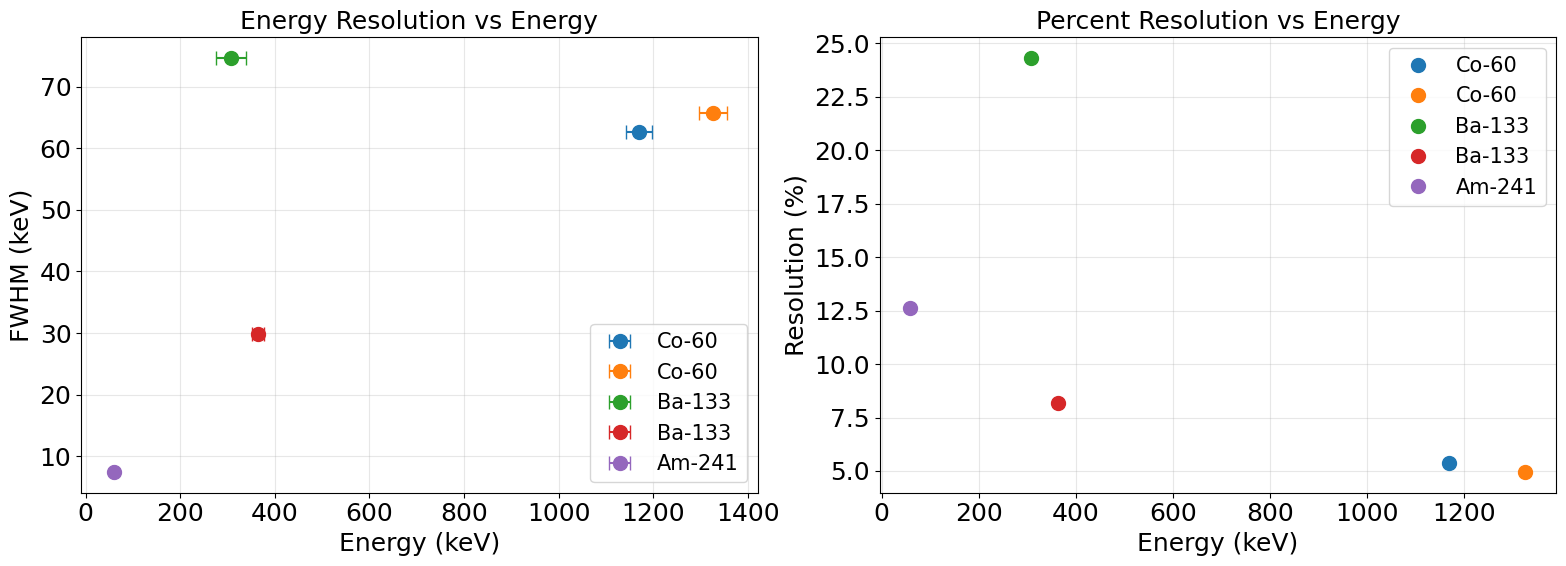

In [575]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for i in range(len(isotopes)):
    ax1.errorbar(
        estimated_energies[i],
        energy_fwhm[i],
        xerr=energy_uncertainties[i],
        fmt="o",
        markersize=10,
        capsize=5,
        label=isotopes[i],
        color=colors[i],
    )

ax1.set_xlabel("Energy (keV)")
ax1.set_ylabel("FWHM (keV)")
ax1.set_title("Energy Resolution vs Energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

for i in range(len(isotopes)):
    ax2.plot(
        estimated_energies[i],
        resolution_percent[i],
        "o",
        markersize=10,
        label=isotopes[i],
        color=colors[i],
    )

ax2.set_xlabel("Energy (keV)")
ax2.set_ylabel("Resolution (%)")
ax2.set_title("Percent Resolution vs Energy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("report/resolution.png", dpi=300, bbox_inches="tight")
plt.show()


In [576]:
unknown_c = np.array([131.76, 169.86, 205.26, 245.36, 417.46])
ra226_peaks = np.array([186, 242, 295, 351, 609])

print("Unknown Isotope Emission Peaks vs Ra-226:")
print("=" * 90)
print(
    f"{'Channel':>10s}  {'Computed Energy (keV)':>25s}  {'Ra-226 Peak (keV)':>18s}  {'Discrepancy':>12s}"
)
print("-" * 90)

for ch, ra_peak in zip(unknown_c, ra226_peaks):
    energy, energy_unc = channel_to_energy(ch)
    energy_r, energy_unc_r = round_unc(energy, energy_unc)
    discrepancy = abs((energy - ra_peak) / energy_unc)
    print(
        f"{ch:>10.2f}  {energy_r:>10.1f} ± {energy_unc_r:<10.1f}  {ra_peak:>18.0f}  {discrepancy:>12.2f}σ"
    )


Unknown Isotope Emission Peaks vs Ra-226:
   Channel      Computed Energy (keV)   Ra-226 Peak (keV)   Discrepancy
------------------------------------------------------------------------------------------
    131.76       188.0 ± 5.0                        186          0.35σ
    169.86       244.0 ± 6.0                        242          0.43σ
    205.26       297.0 ± 7.0                        295          0.33σ
    245.36       357.0 ± 8.0                        351          0.75σ
    417.46       614.0 ± 14.0                       609          0.36σ


In [577]:
print("\nLaTeX Table for Unknown Isotope (Copy-Pastable):")
print("=" * 80)
print()

print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Unknown Isotope Emission Peaks Compared to Ra-226}")
print("\\begin{tabular}{cccc}")
print("\\hline")
print("Channel & Computed Energy & Ra-226 Peak & Discrepancy \\\\")
print("(Index) & (keV) & (keV) & \\\\")
print("\\hline")

for ch, ra_peak in zip(unknown_c, ra226_peaks):
    energy, energy_unc = channel_to_energy(ch)
    energy_r, energy_unc_r = round_unc(energy, energy_unc)
    discrepancy = abs((energy - ra_peak) / energy_unc)
    print(
        f"${ch:.2f}$ & ${energy_r} \\pm {energy_unc_r}$ & ${ra_peak:.0f}$ & ${discrepancy:.2f}\\sigma$ \\\\"
    )

print("\\hline")
print("\\end{tabular}")
print("\\label{tab:unknown}")
print("\\end{table}")



LaTeX Table for Unknown Isotope (Copy-Pastable):

\begin{table}[h]
\centering
\caption{Unknown Isotope Emission Peaks Compared to Ra-226}
\begin{tabular}{cccc}
\hline
Channel & Computed Energy & Ra-226 Peak & Discrepancy \\
(Index) & (keV) & (keV) & \\
\hline
$131.76$ & $188.0 \pm 5.0$ & $186$ & $0.35\sigma$ \\
$169.86$ & $244.0 \pm 6.0$ & $242$ & $0.43\sigma$ \\
$205.26$ & $297.0 \pm 7.0$ & $295$ & $0.33\sigma$ \\
$245.36$ & $357.0 \pm 8.0$ & $351$ & $0.75\sigma$ \\
$417.46$ & $614.0 \pm 14.0$ & $609$ & $0.36\sigma$ \\
\hline
\end{tabular}
\label{tab:unknown}
\end{table}


In [578]:
unknown_c = np.array([131.76, 169.86, 205.26, 245.36, 417.46])

In [579]:
cesium_137_centroid = 450.58
cesium_137_fwhm = 33.2410

In [580]:
channel_to_energy(450.58, 33.2410)

(np.float64(663.4891910333133), np.float64(49.82142068723227))